## Setup

In [86]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [87]:
import sys

sys.path.append("..")

In [88]:
!pip install vectorbt git+https://github.com/rongardF/tvdatafeed.git

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

## Get data

In [89]:
from tvDatafeed import TvDatafeed, Interval

# Initialize TvDatafeed (you might need to provide username/password if you have a TradingView account and want to fetch more data)
tv = TvDatafeed()

In [90]:
# Get historical data for BTCUSDT from BINANCE
# Adjust interval and n_bars as needed
xauusd_data = tv.get_hist(symbol='XAUUSD', exchange='PEPPERSTONE', interval=Interval.in_daily, n_bars=5000)

if xauusd_data is None:
    raise Exception("Could not retrieve data. Please check symbol, exchange, and your internet connection.")

## Prepare data

In [91]:
data = xauusd_data.copy()
data.columns = [str(col).capitalize() for col in data.columns]

close = data['Close']
print(f"Data shape: {data.shape}")
print(f"Date range: {data.index[0]} to {data.index[-1]}")

Data shape: (5000, 6)
Date range: 2006-11-09 06:00:00 to 2026-04-10 05:00:00


## Walk-Forward Splits

In [92]:
TRAIN_DAYS = 1000
TEST_DAYS = 250

splits = []
start_idx = 0
while start_idx + TRAIN_DAYS + TEST_DAYS <= len(data):
    train = data.iloc[start_idx: start_idx + TRAIN_DAYS]
    test  = data.iloc[start_idx + TRAIN_DAYS: start_idx + TRAIN_DAYS + TEST_DAYS]
    splits.append((train, test))
    start_idx += TEST_DAYS

print(f"Total splits: {len(splits)}")

Total splits: 16


## Signal Generation Helpers

In [93]:
def compute_ema(series, span):
    return series.ewm(span=span, adjust=False).mean()

def compute_rsi(series, period=14):
    delta = series.diff()
    up   = delta.clip(lower=0)
    down = -delta.clip(upper=0)
    ema_up   = up.ewm(com=period - 1, adjust=False).mean()
    ema_down = down.ewm(com=period - 1, adjust=False).mean()
    rs = ema_up / ema_down
    return 100 - (100 / (1 + rs))

def generate_signals(close, ema_fast=20, ema_slow=50, ema_trend=200, rsi_period=14):
    ema_f = compute_ema(close, ema_fast)
    ema_s = compute_ema(close, ema_slow)
    ema_t = compute_ema(close, ema_trend)
    rsi   = compute_rsi(close, rsi_period)

    # Crossover: fast crosses above slow
    cross_up   = (ema_f > ema_s) & (ema_f.shift(1) <= ema_s.shift(1))
    cross_down = (ema_s > ema_f) & (ema_s.shift(1) <= ema_f.shift(1))

    long_entries  = cross_up   & (rsi > 50) & (close > ema_t)
    short_entries = cross_down & (rsi < 50) & (close < ema_t)
    long_exits    = cross_down
    short_exits   = cross_up

    return long_entries, long_exits, short_entries, short_exits

## Optimization per Split (Grid Search)

In [94]:
import numpy as np
import vectorbt as vbt
from itertools import product

ema_fast_range  = range(10, 40, 2)
ema_slow_range  = range(50, 150, 2)

def run_split_optimize(test_close):
    best_score  = -np.inf
    best_stats  = None
    best_params = None

    for ema_fast, ema_slow in product(ema_fast_range, ema_slow_range):
        if ema_fast >= ema_slow:
            continue

        le, lx, se, sx = generate_signals(
            test_close,
            ema_fast=ema_fast,
            ema_slow=ema_slow,
        )

        pf = vbt.Portfolio.from_signals(
            test_close,
            entries=le, exits=lx,
            short_entries=se, short_exits=sx,
            size=0.95,
            size_type='percent',
            init_cash=100_000,
            fees=0.001,
            freq='1D',
            upon_opposite_entry='ignore',
            upon_dir_conflict='ignore',
        )

        ann_return = pf.annualized_return() * 100
        max_dd     = pf.max_drawdown() * 100
        score      = ann_return / -max_dd if max_dd < 0 else 0

        if score > best_score:
            best_score  = score
            best_stats  = pf
            best_params = (ema_fast, ema_slow)

    return best_stats, best_params

## Run Walk-Forward

In [95]:
all_pf     = []
all_params = []

for i, (train_data, test_data) in enumerate(splits):
    test_close = test_data['Close']
    pf, params = run_split_optimize(test_close)
    all_pf.append(pf)
    all_params.append(params)

    sharpe = pf.sharpe_ratio()
    ret    = pf.total_return() * 100
    dd     = pf.max_drawdown() * 100
    trades = pf.trades.count()
    print(f"Split {i+1}: params={params}  Sharpe={sharpe:.2f}  Return={ret:.2f}%  MaxDD={dd:.2f}%  Trades={trades}")

print("\n=== Walk-Forward Complete ===")

Split 1: params=(10, 56)  Sharpe=2.88  Return=42.93%  MaxDD=-7.03%  Trades=2
Split 2: params=(10, 88)  Sharpe=0.77  Return=8.79%  MaxDD=-8.85%  Trades=2
Split 3: params=(14, 98)  Sharpe=1.25  Return=13.63%  MaxDD=-9.79%  Trades=2
Split 4: params=(20, 50)  Sharpe=0.42  Return=3.46%  MaxDD=-7.80%  Trades=3
Split 5: params=(30, 50)  Sharpe=0.51  Return=3.09%  MaxDD=-5.70%  Trades=3
Split 6: params=(16, 112)  Sharpe=1.48  Return=17.59%  MaxDD=-7.77%  Trades=2
Split 7: params=(18, 50)  Sharpe=1.13  Return=7.27%  MaxDD=-7.90%  Trades=3
Split 8: params=(10, 128)  Sharpe=0.15  Return=0.68%  MaxDD=-8.31%  Trades=5
Split 9: params=(30, 94)  Sharpe=1.84  Return=5.72%  MaxDD=-1.76%  Trades=2
Split 10: params=(10, 138)  Sharpe=1.55  Return=20.56%  MaxDD=-11.81%  Trades=1
Split 11: params=(10, 86)  Sharpe=0.94  Return=9.61%  MaxDD=-10.57%  Trades=3
Split 12: params=(16, 54)  Sharpe=0.30  Return=1.57%  MaxDD=-5.12%  Trades=3
Split 13: params=(10, 136)  Sharpe=0.85  Return=7.15%  MaxDD=-7.01%  Trades=

## Results Summary

In [96]:
sharpes    = [pf.sharpe_ratio()       for pf in all_pf]
returns    = [pf.total_return()*100   for pf in all_pf]
max_dds    = [pf.max_drawdown()*100   for pf in all_pf]
sortinos   = [pf.sortino_ratio()      for pf in all_pf]
win_rates  = [pf.trades.win_rate()*100 for pf in all_pf]
num_trades = [pf.trades.count()       for pf in all_pf]

print('=' * 75)
print('WALK-FORWARD RESULTS SUMMARY')
print('=' * 75)
print(f"{'Split':<6} {'Test Period':<28} {'Sharpe':>8} {'Return%':>10} {'MaxDD%':>10} {'Trades':>7}")
print('-' * 75)

for i, (pf, (train_d, test_d)) in enumerate(zip(all_pf, splits)):
    period = f"{test_d.index[0].date()} to {test_d.index[-1].date()}"
    print(f"{i+1:<6} {period:<28} {sharpes[i]:>8.2f} {returns[i]:>10.2f} {max_dds[i]:>10.2f} {num_trades[i]:>7}")

print('-' * 75)
print(f"{'MEAN':<6} {'':<28} {np.mean(sharpes):>8.2f} {np.mean(returns):>10.2f} {np.mean(max_dds):>10.2f} {np.mean(num_trades):>7.1f}")
print(f"{'STD':<6}  {'':<28} {np.std(sharpes):>8.2f}  {np.std(returns):>8.2f}  {np.std(max_dds):>8.2f}  {np.std(num_trades):>7.1f}")
print('=' * 75)

WALK-FORWARD RESULTS SUMMARY
Split  Test Period                    Sharpe    Return%     MaxDD%  Trades
---------------------------------------------------------------------------
1      2010-09-21 to 2011-09-05         2.88      42.93      -7.03       2
2      2011-09-06 to 2012-08-23         0.77       8.79      -8.85       2
3      2012-08-24 to 2013-09-03         1.25      13.63      -9.79       2
4      2013-09-04 to 2014-08-22         0.42       3.46      -7.80       3
5      2014-08-25 to 2015-08-12         0.51       3.09      -5.70       3
6      2015-08-13 to 2016-08-01         1.48      17.59      -7.77       2
7      2016-08-02 to 2017-07-20         1.13       7.27      -7.90       3
8      2017-07-21 to 2018-07-10         0.15       0.68      -8.31       5
9      2018-07-11 to 2019-06-28         1.84       5.72      -1.76       2
10     2019-07-01 to 2020-06-17         1.55      20.56     -11.81       1
11     2020-06-18 to 2021-06-07         0.94       9.61     -10.57    

## Monte Carlo

In [97]:
n_sims = 5000
simulated_returns = np.random.choice(returns, size=n_sims, replace=True)

ci_lower  = np.percentile(simulated_returns, 5)
ci_upper  = np.percentile(simulated_returns, 95)
prob_loss = (simulated_returns < 0).mean() * 100

print('=' * 50)
print('MONTE CARLO ANALYSIS (5000 simulations)')
print('=' * 50)
print(f"Expected Return:     {np.mean(simulated_returns):.2f}%")
print(f"95% CI:              ({ci_lower:.2f}%, {ci_upper:.2f}%)")
print(f"Probability of Loss: {prob_loss:.1f}%")
print(f"Worst Case (5th %):  {np.percentile(simulated_returns, 5):.2f}%")
print('=' * 50)

MONTE CARLO ANALYSIS (5000 simulations)
Expected Return:     14.36%
95% CI:              (0.68%, 43.08%)
Probability of Loss: 0.0%
Worst Case (5th %):  0.68%


## Visualization

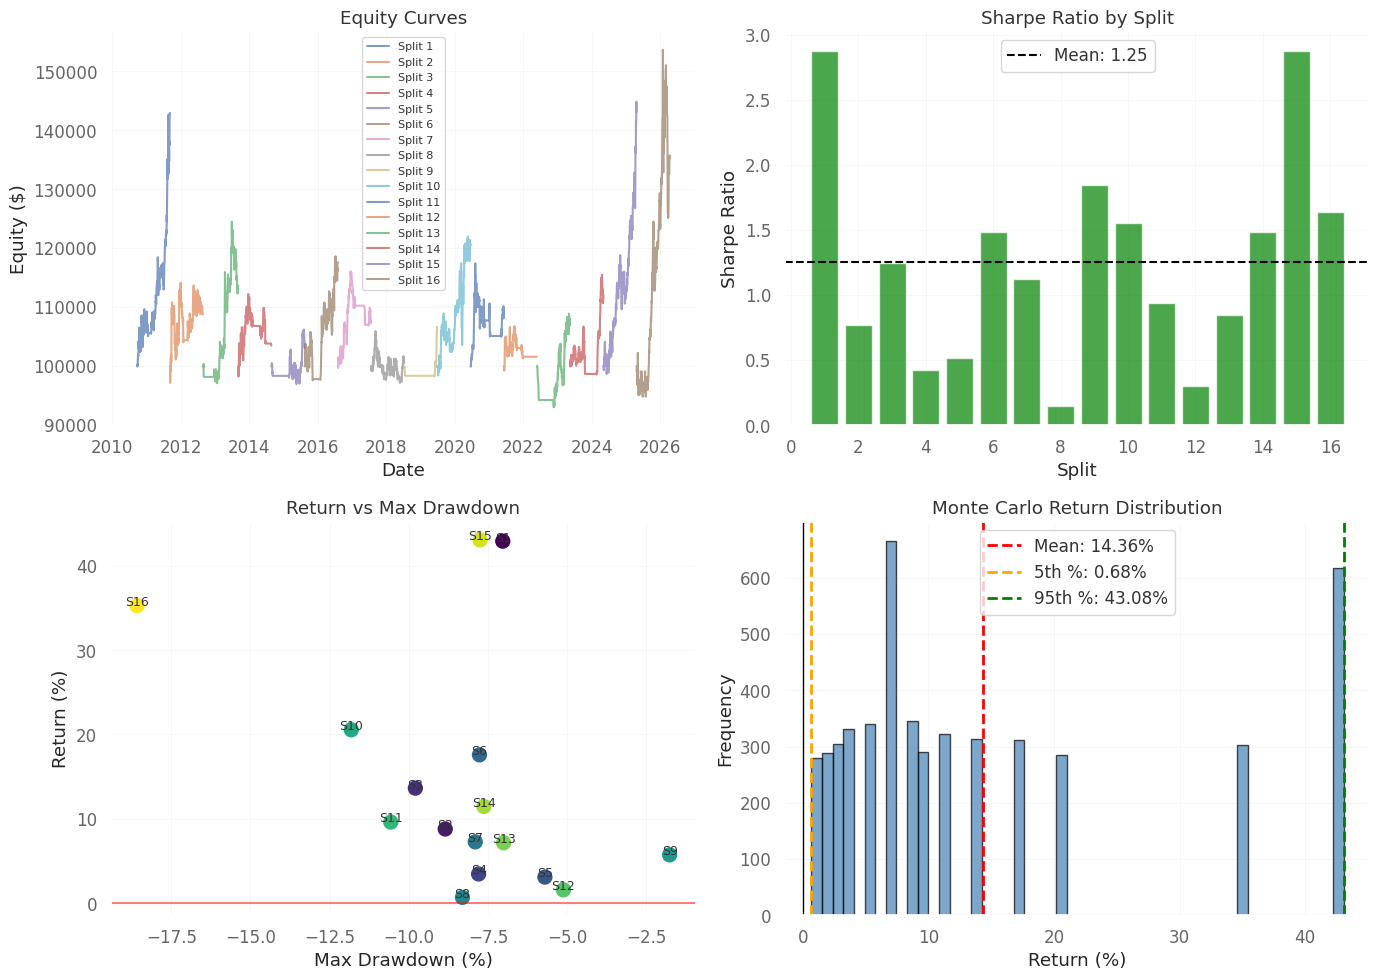

In [98]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Equity curves
ax1 = axes[0, 0]
for i, pf in enumerate(all_pf):
    eq = pf.value()
    ax1.plot(eq.index, eq.values, alpha=0.7, label=f'Split {i+1}')
ax1.set_title('Equity Curves')
ax1.set_xlabel('Date')
ax1.set_ylabel('Equity ($)')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# 2. Sharpe ratio
ax2 = axes[0, 1]
colors = ['green' if s > 0 else 'red' for s in sharpes]
ax2.bar(range(1, len(sharpes)+1), sharpes, color=colors, alpha=0.7)
ax2.axhline(y=np.mean(sharpes), color='black', linestyle='--', label=f'Mean: {np.mean(sharpes):.2f}')
ax2.set_title('Sharpe Ratio by Split')
ax2.set_xlabel('Split')
ax2.set_ylabel('Sharpe Ratio')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Return vs Drawdown
ax3 = axes[1, 0]
ax3.scatter(max_dds, returns, s=100, c=range(len(returns)), cmap='viridis')
for i, (dd, ret) in enumerate(zip(max_dds, returns)):
    ax3.annotate(f'S{i+1}', (dd, ret), fontsize=9, ha='center')
ax3.axhline(y=0, color='red', linestyle='-', alpha=0.5)
ax3.set_title('Return vs Max Drawdown')
ax3.set_xlabel('Max Drawdown (%)')
ax3.set_ylabel('Return (%)')
ax3.grid(True, alpha=0.3)

# 4. Monte Carlo histogram
ax4 = axes[1, 1]
ax4.hist(simulated_returns, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax4.axvline(x=np.mean(simulated_returns), color='red',    linestyle='--', linewidth=2, label=f'Mean: {np.mean(simulated_returns):.2f}%')
ax4.axvline(x=ci_lower,                   color='orange', linestyle='--', linewidth=2, label=f'5th %: {ci_lower:.2f}%')
ax4.axvline(x=ci_upper,                   color='green',  linestyle='--', linewidth=2, label=f'95th %: {ci_upper:.2f}%')
ax4.axvline(x=0,                           color='black',  linestyle='-',  linewidth=1)
ax4.set_title('Monte Carlo Return Distribution')
ax4.set_xlabel('Return (%)')
ax4.set_ylabel('Frequency')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Final Summary

In [99]:
POSITION_SIZE = 0.10

print('=' * 60)
print('FINAL BACKTEST SUMMARY')
print('=' * 60)
print(f'Strategy: EMA(20,50) Crossover + RSI(14) Confirmation')
print(f'Position Sizing: {POSITION_SIZE*100:.0f}% per trade')
print(f'Walk-Forward: {TRAIN_DAYS} days train / {TEST_DAYS} days test')
print(f'Number of Splits: {len(splits)}')
print('-' * 60)
print(f"Mean Sharpe Ratio:    {np.mean(sharpes):.2f}")
print(f"Mean Return:          {np.mean(returns):.2f}%")
print(f"Mean Max Drawdown:    {np.mean(max_dds):.2f}%")
print(f"Mean Win Rate:        {np.mean(win_rates):.1f}%")
print(f"Mean Sortino Ratio:   {np.mean(sortinos):.2f}")
print('-' * 60)
print(f"Monte Carlo Expected Return: {np.mean(simulated_returns):.2f}%")
print(f"Monte Carlo 95% CI: ({ci_lower:.2f}%, {ci_upper:.2f}%)")
print(f"Probability of Loss: {prob_loss:.1f}%")
print('=' * 60)
print(f"\nCalmar-like ratio: {np.mean(returns) / abs(np.mean(max_dds)):.4f}")

FINAL BACKTEST SUMMARY
Strategy: EMA(20,50) Crossover + RSI(14) Confirmation
Position Sizing: 10% per trade
Walk-Forward: 1000 days train / 250 days test
Number of Splits: 16
------------------------------------------------------------
Mean Sharpe Ratio:    1.25
Mean Return:          14.49%
Mean Max Drawdown:    -8.34%
Mean Win Rate:        61.2%
Mean Sortino Ratio:   1.99
------------------------------------------------------------
Monte Carlo Expected Return: 14.36%
Monte Carlo 95% CI: (0.68%, 43.08%)
Probability of Loss: 0.0%

Calmar-like ratio: 1.7383


In [100]:
print(np.mean(returns) / abs(np.mean(max_dds)))

1.7383499738684591


In [101]:
le, lx, se, sx = generate_signals(
    close,
    ema_fast=30,
    ema_slow=50,
)

pf = vbt.Portfolio.from_signals(
    close,
    entries=le, exits=lx,
    short_entries=se, short_exits=sx,
    size=0.95,
    size_type='percent',
    init_cash=100_000,
    fees=0.001,
    freq='1D',
    upon_opposite_entry='ignore',
    upon_dir_conflict='ignore',
)

In [102]:
sharpe = pf.sharpe_ratio()
ret    = pf.total_return() * 100
dd     = pf.max_drawdown() * 100
trades = pf.trades.count()
print(f"Sharpe={sharpe:.2f}  Return={ret:.2f}%  MaxDD={dd:.2f}%  Trades={trades}")

Sharpe=0.66  Return=253.93%  MaxDD=-30.48%  Trades=32


In [103]:
print(np.mean(ret) / abs(np.mean(dd)))

8.329873666831112
